In [36]:
import numpy as np
from landlab import RasterModelGrid
from landlab.components import FlowAccumulator
from crisis import Crisis
from landlab import imshow_grid
import matplotlib.pyplot as plt

In [37]:
# Create 5x5 grid
grid = RasterModelGrid((5, 5),xy_spacing=10)

# Add required fields
grid.add_zeros("topographic__elevation", at="node")
grid.add_zeros("soil__depth", at="node")
grid.add_zeros("bedrock__elevation", at="node")

# Add random noise to bedrock elevation
grid.at_node["bedrock__elevation"][:] = np.random.uniform(10, 50, grid.number_of_nodes)

# Set topographic elevation equal to bedrock elevation
grid.at_node['topographic__elevation'][:] = grid.at_node["bedrock__elevation"][:]+grid.at_node["soil__depth"][:]

In [38]:
# Initialize FlowAccumulator
fa = FlowAccumulator(grid)

# Initialize Crisis
crisis = Crisis(grid, cohesion=0.0, friction_angle=30.0)

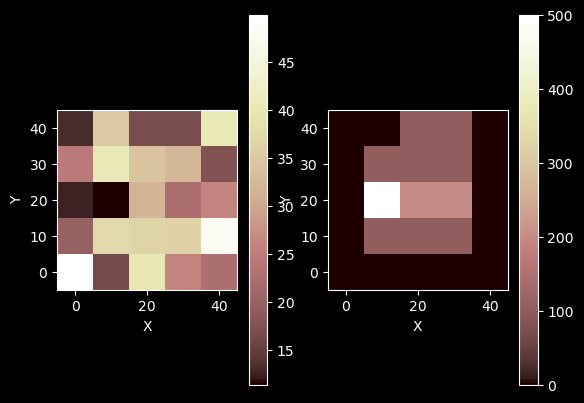

In [39]:
# Run flow accumulator
fa.run_one_step()

fig, ax = plt.subplots(1,2)
plt.axes(ax[0])
# Plot topographic__elevation
imshow_grid(grid, 'topographic__elevation')

#Plot flow accumulation, drainage area
plt.axes(ax[1])
imshow_grid(grid,'drainage_area')